In [1]:
from pathlib import Path

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel")
udel_subj = udel_dir/f"U01_UDEL_{subid}_01_v3"
udel_anatomy = udel_subj/f"U01_UDEL_{subid}_01_SLANT"
fs_dir = udel_dir / "fsruns" / subid
mre_dir = Path("/home/oana/MRE_analysis") / subid


# MRE volumes
mre_files = {
    "stiffness": mre_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": mre_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": mre_dir / "MRE_imag_in_T1_space.nii.gz",
}
#t1w_path=fs_dir/"mri/T1.mgz"
# T1W and T2w paths for later myelin calculation
#t1w_path = udel_anatomy/f"U01_UDEL_{subid}_01_MPRAGEPre_norm_deface.nii.gz"
#t2w_path = udel_anatomy/f"U01_UDEL_{subid}_01_3DT2_norm.nii.gz"
t1w_path = mre_dir/"T1_MNI_in_fs_space.nii.gz"
t2w_path = mre_dir/"T2_MNI_in_fs_space.nii.gz"
#udel_anatomy/f"U01_UDEL_{subid}_01_3DT2_norm.nii.gz"

brainmask_path = mre_dir /"brainmask_fs.nii.gz"


In [2]:
import numpy as np
import nibabel as nib
from cortech import Cortex
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

cortex = Cortex.from_freesurfer_subject_dir(fs_dir, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
#for hemi in [cortex.lh, cortex.rh]:
#    hemi.white.smooth_taubin(n_iter=5, inplace=True)
#    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


mask_img = nib.load(str(brainmask_path))
mask_data = mask_img.get_fdata()
mask_binary = mask_data > 0  # inside brain

#surface_brainmask = {hemi: mid_layers[hemi].interpolate_to_nodes(mask_data, mask_affine) for hemi in ["lh","rh"]}

#surface_brainmask = {hemi: surface_brainmask[hemi] > 0.5 for hemi in ["lh","rh"]}

# interpolate all MRE data
surface_mre = {}

for name, vol_path in mre_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_mre[name] = {hemi: mid_layers[hemi].interpolate_to_nodes(data, affine) for hemi in ["lh", "rh"]}


# Myelin map
t1_img = nib.load(str(t1w_path))
t2_img = nib.load(str(t2w_path))
#mask_img = nib.load(str(brainmask_path))

t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()
#mask_data = mask_img.get_fdata().astype(bool)

t1_affine = t1_img.affine


t1_masked = np.where(mask_binary, t1_data, 0)
t2_masked = np.where(mask_binary, t2_data, 0)

#compute ratio only there both images arep positive
valid = (t1_masked > 0) & (t2_masked > 0)
myelin_data = np.where(valid, t1_masked/(t2_masked + 1e-3), 0)

# Interpolate myelin map to surface
surface_myelin = {hemi: mid_layers[hemi].interpolate_to_nodes(myelin_data, t1_affine) for hemi in ["lh", "rh"]}


# Regions 
#region_img = nib.load(str(regions_path))
#region_data = region_img.get_fdata().astype(int)
#region_affine = region_data.affine
#surface_regions = {hemi: mid_layers[hemi].interpolate_to_nodes(region_data, region_affine, method ="nearest").astype(int) for hemi in ["lh", "rh"]}

#Load parcellation
aparc = {
    "lh": nib.freesurfer.io.read_annot(fs_dir / "label" / "lh.aparc.a2009s.annot"),
    "rh": nib.freesurfer.io.read_annot(fs_dir / "label" / "rh.aparc.a2009s.annot"),
}


#Add geometry parameters

from nibabel.freesurfer import read_morph_data

curvature = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.curv"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.curv"),
}
#lh.inflated.K
#lh.inflated.H

thickness = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.thickness"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.thickness"),
}

sulcal_depth = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.sulc"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.sulc"),
}


In [34]:
print(t1_data.shape)
print(t2_data.shape)

(241, 286, 241)
(241, 286, 241)


In [ ]:
myelinimage=nib.Nifti1Image(myelin_data,t1_affine)
nib.save(myelinimage,mre_dir/'Myelin.nii.gz')

In [3]:

aseg_img = nib.load(fs_dir / "mri" / "aseg.mgz")
aseg_data = aseg_img.get_fdata()
wm_mask = (aseg_data == 2) | (aseg_data == 41)
print(aseg_data.shape)
stiff_vol = nib.load(mre_dir / "MRE_stiffness_in_T1_space.nii.gz").get_fdata()
print(stiff_vol.shape)
print(myelin_data.shape)
valid = (
    wm_mask &
    np.isfinite(stiff_vol) &
    np.isfinite(myelin_data) &
    (stiff_vol > 0) &
    (myelin_data > 0)
)

stiff_wm = stiff_vol[valid]
myelin_wm = myelin_data[valid]

(256, 256, 256)
(256, 256, 256)
(256, 256, 256)


In [4]:
import pandas as pd

stiff_min=99 

for hemi in ["lh","rh"]:
    labels, ctab, names = aparc[hemi]
    labels = labels.astype(int)

    #Extract hemi specific arrays
    curv = curvature[hemi].astype(np.float64)
    thick= thickness[hemi].astype(np.float64)
    stiff = surface_mre["stiffness"][hemi].astype(np.float64)
    real = surface_mre["real"][hemi].astype(np.float64) #shear real (storage modulus)
    imag = surface_mre["imag"][hemi].astype(np.float64) #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi].astype(np.float64)
    myelin = surface_myelin[hemi].astype(np.float64)

    #Stiffness mask that eliminates values around zero
    stiff_mask=(np.isfinite(stiff) & (stiff >= stiff_min))

    #Apply the mask to the other 
    curv_m=curv[stiff_mask]
    thick_m=thick[stiff_mask]
    stiff_m = stiff[stiff_mask]
    real_m =real[stiff_mask]
    imag_m = imag[stiff_mask]
    sulc_m =sulc[stiff_mask]
    myelin_m=myelin[stiff_mask]
    labels_m=labels[stiff_mask]

    names= np.array([n.decode("utf-8") for n in names])
    #Transform shear stiffness, storage modulus and loss modulus to kPa
    stiff_kpa = stiff_m/1000
    real_kpa = real_m/1000
    imag_kpa = imag_m/1000

    #Create a DataFrame 
    df = pd.DataFrame({
        "curvature":curv_m,
        "thickness":thick_m,
        "sulcal_depth":sulc_m,
        "stiffness":stiff_kpa,
        "real":real_kpa,
        "imag":imag_kpa,
        "myelin":myelin_m,
        "label":labels_m,
    })

    df["parcel"]=df["label"].map({i:names[i] for i in range(len(names))})
df.head()


,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin,label,parcel
0,-0.076381,2.733513,-4.104676,0.149998,0.126377,0.064278,0.527922,43,Pole_occipital
1,-0.109680,2.197700,-5.186806,0.108453,0.068527,0.064107,0.569056,43,Pole_occipital
2,-0.317661,2.030369,-6.008362,0.130512,0.094126,0.070193,0.437101,43,Pole_occipital
3,-0.274947,2.255861,-6.151323,0.101734,0.069711,0.057153,0.434860,43,Pole_occipital
4,-0.044668,2.824182,-3.661626,0.251696,0.207358,0.113128,0.524651,43,Pole_occipital


In [5]:
from scipy.stats import spearmanr
results=[]

for parcel, g in df.groupby("parcel"):
    if len(g)<50:
        continue

    r,p=spearmanr(g["stiffness"],g["sulcal_depth"],nan_policy="omit")

    results.append({
        "parcel":parcel,
        "n_vertices":len(g),
        "r_val":r,
        "p_val":p
    })

parcel_stats=pd.DataFrame(results)
parcel_stats.sort_values("r_val",ascending=True)

,parcel,n_vertices,r_val,p_val
48,S_circular_insula_sup,1730,-0.552156,1.207775e-138
39,Lat_Fis-ant-Vertical,227,-0.330580,3.446638e-07
19,G_oc-temp_med-Lingual,3456,-0.258559,6.645302e-54
30,G_rectus,727,-0.237899,8.197643e-11
38,Lat_Fis-ant-Horizont,515,-0.233557,8.244291e-08
...,...,...,...,...
60,S_occipital_ant,842,0.655692,1.292853e-104
72,S_temporal_sup,8095,0.660509,0.000000e+00
49,S_collat_transv_ant,1213,0.666125,2.043078e-156
7,G_and_S_subcentral,1778,0.716902,1.566859e-280


In [6]:
from statsmodels.stats.multitest import multipletests

parcel_stats["p_fdr"]=multipletests(parcel_stats["p_val"],method="fdr_bh")[1]
parcel_stats.sort_values("p_fdr",ascending=True)

,parcel,n_vertices,r_val,p_val,p_fdr
5,G_and_S_occipital_inf,1426,0.887543,0.000000e+00,0.000000e+00
16,G_front_sup,6771,0.489447,0.000000e+00,0.000000e+00
51,S_front_inf,3236,0.644219,0.000000e+00,0.000000e+00
72,S_temporal_sup,8095,0.660509,0.000000e+00,0.000000e+00
7,G_and_S_subcentral,1778,0.716902,1.566859e-280,2.318952e-279
...,...,...,...,...,...
10,G_cingul-Post-ventral,339,-0.060390,2.675115e-01,2.749424e-01
12,G_front_inf-Opercular,1541,-0.028377,2.655963e-01,2.749424e-01
62,S_orbital_lateral,615,0.044830,2.669749e-01,2.749424e-01
11,G_cuneus,2510,0.017317,3.858222e-01,3.911074e-01


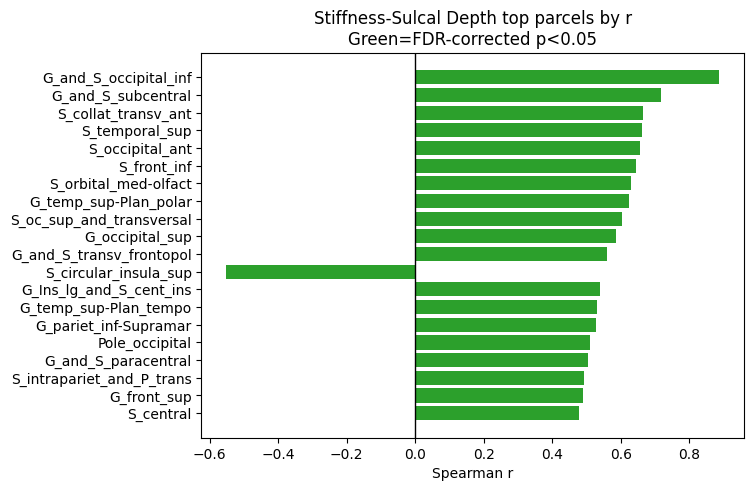

In [7]:
parcel_stats["abs_r"]=parcel_stats["r_val"].abs()
top=parcel_stats.sort_values("abs_r",ascending=False).head(20)
colors=["tab:green" if p<0.05 else "tab:red" for p in top["p_fdr"]]

plt.figure(figsize=(7,5))
plt.barh(top["parcel"],top["r_val"], color=colors)
plt.axvline(0,color="k",lw=1)
plt.xlabel("Spearman r")
plt.title("Stiffness-Sulcal Depth top parcels by r\nGreen=FDR-corrected p<0.05")
plt.gca().invert_yaxis()
plt.show()

In [8]:
mechanical={
    "stiffness":"stiffness",
    "storage":"real",
    "loss":"imag",
    "myelin":"myelin",
}
geometric={
    #"curvature":"curvature",
    "thickness":"thickness",
    "sulcal_depth":"sulcal_depth",
    "curvature":"curvature",
    "myelin":"myelin"
}

from scipy.stats import spearmanr
results=[]

for parcel, g in df.groupby("parcel"):

    if len(g)<50:
        continue

    for mech_name, mech_col in mechanical.items():
        for geom_name, geom_col in geometric.items():
            
            x=g[mech_col]
            y=g[geom_col]
            

            r,p=spearmanr(x,y)

            results.append({
                "parcel":parcel,
                "mechanical":mech_name,
                "geometric":geom_name,
                "r_val":r,
                "p_val":p
            })

corr_df=pd.DataFrame(results)
corr_df.sort_values("r_val",ascending=False)

,parcel,mechanical,geometric,r_val,p_val
47,G_and_S_cingul-Mid-Ant,myelin,myelin,1.000000,0.000000e+00
703,S_calcarine,myelin,myelin,1.000000,0.000000e+00
687,Pole_temporal,myelin,myelin,1.000000,0.000000e+00
719,S_central,myelin,myelin,1.000000,0.000000e+00
1183,S_temporal_transverse,myelin,myelin,1.000000,0.000000e+00
...,...,...,...,...,...
212,G_front_inf-Orbital,storage,thickness,-0.673079,1.449927e-68
1177,S_temporal_transverse,loss,sulcal_depth,-0.696312,6.221191e-42
636,Lat_Fis-ant-Vertical,myelin,thickness,-0.707304,9.566253e-36
617,Lat_Fis-ant-Horizont,loss,sulcal_depth,-0.708758,9.103356e-80


In [9]:
corr_df.groupby("geometric").size()


geometric
curvature       296
myelin          296
sulcal_depth    296
thickness       296
dtype: int64

In [10]:
from statsmodels.stats.multitest import multipletests

corr_df["p_fdr"] = np.nan

for (mech, geom), idx in corr_df.groupby(
    ["mechanical", "geometric"]
).groups.items():

    pvals = corr_df.loc[idx, "p_val"]
    corr_df.loc[idx, "p_fdr"] = multipletests(
        pvals, method="fdr_bh"
    )[1]


In [11]:
corr_df.query("p_fdr < 0.05").groupby("geometric").size()


geometric
curvature       275
myelin          254
sulcal_depth    266
thickness       265
dtype: int64

In [12]:
corr_df.sort_values("p_fdr",ascending=True)

,parcel,mechanical,geometric,r_val,p_val,p_fdr
716,S_central,myelin,thickness,0.681153,0.000000,0.000000
719,S_central,myelin,myelin,1.000000,0.000000,0.000000
351,G_occipital_middle,myelin,myelin,1.000000,0.000000,0.000000
1087,S_precentral-inf-part,myelin,myelin,1.000000,0.000000,0.000000
1157,S_temporal_sup,storage,sulcal_depth,0.707489,0.000000,0.000000
...,...,...,...,...,...,...
1015,S_orbital_med-olfact,storage,myelin,0.005414,0.871361,0.871361
195,G_front_inf-Opercular,stiffness,myelin,0.003163,0.901273,0.901273
109,G_and_S_paracentral,myelin,sulcal_depth,-0.002046,0.944826,0.957769
173,G_cingul-Post-ventral,myelin,sulcal_depth,0.001442,0.978903,0.978903


In [13]:
#SUmmary of statistically reliable parcels
summary = (
    corr_df
    .query("p_fdr < 0.05")
    .groupby(["mechanical", "geometric"])
    .agg(mean_r_values=("r_val", "mean"))
    .unstack()
)


In [14]:
print(summary)


           mean_r_values                                 
geometric      curvature    myelin sulcal_depth thickness
mechanical                                               
loss            0.272823  0.039715     0.270528 -0.111826
myelin          0.284578  1.000000     0.106405 -0.243044
stiffness       0.271781  0.082086     0.296540 -0.102442
storage         0.261260  0.088109     0.288466 -0.116956


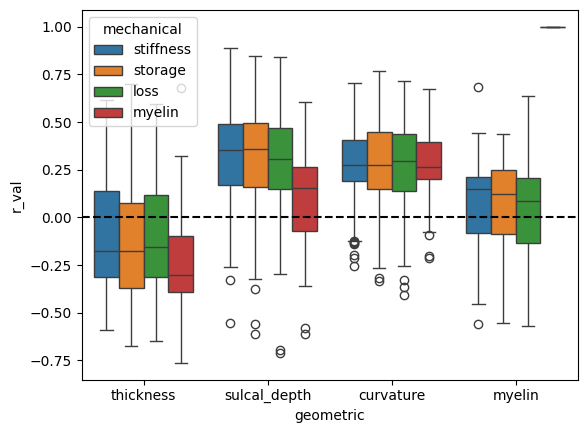

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sig = corr_df.query("p_fdr < 0.05")

sns.boxplot(
    data=sig,
    x="geometric",
    y="r_val",
    hue="mechanical"
)
plt.axhline(0, color="k", linestyle="--")
plt.show()
